In [1]:
import os
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
import sklearn.model_selection
import tensorflow as tf
import cv2
import pandas as pd
from obspy import read, Trace
import numpy as np
import matplotlib.pyplot as plt

2023-06-22 14:41:53.834781: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-22 14:41:53.836623: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-22 14:41:53.869408: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-22 14:41:53.870329: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-22 14:41:54.498108: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
model = tf.keras.models.load_model('./model8k_v4_org')

In [3]:
"""
8000 / 80 = 100

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

model = models.Sequential(
    [
        layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
"""

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 7998, 512)         2048      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 3999, 512)        0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 3997, 64)          98368     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 1998, 64)         0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 1996, 32)          6176      
                                                                 
 dropout (Dropout)           (None, 1996, 32)          0

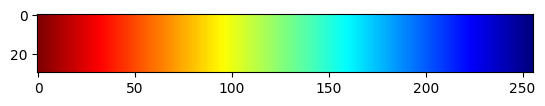

In [4]:

color_img = cv2.imread('colorscale_jet.jpg')
colors = []
for i in range(0,len(color_img[15]), 5):
  colors.append(color_img[15][i])

plt.imshow(color_img)

In [5]:

def overlay_image(pred, pred_list, divide_number = 80):

    image = cv2.imread('trace_image.png')
    overlay = image.copy()

    # image sizes
    # print(overlay.shape)

    # Rectangle parameters
    x, y, w, h = 80, 60, 680, 150

    rect_with_offset = w // divide_number

    for i in range(divide_number):
        color_index = (100 - int(pred_list[i] * 100))
        # color_index = color_index
        # if pred < 0.49:
        #     color_index = 50 - color_index

        # print(color_index)
        b, g, r = colors[color_index // 2]
        overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), (int(b), int(g), int(r)), -1)

    # A filled rectangle
    # cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)

    alpha = 0.5  # Transparency factor.
    # Following line overlays transparent rectangle
    # over the image
    image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    cv2.imwrite("attention_signal.jpg", image_new)

    # concatenate both images
    image_new = cv2.vconcat([image, image_new])

    # cv2.imshow('Image', image_new)
    # cv2.waitKey(0)

    # import matplotlib.pyplot as plt
    # size = (10, 10)
    # fig, ax = plt.subplots(figsize=size, )
    # ax.imshow(image_new)
    # plt.show()

    return image_new

    # cv2.destroyAllWindows()


In [6]:

def colorize(path, divide_number = 80, size_of_length_signal = 8000):

    trace = read(path)[0]
    # print(f" 1 {trace.data.shape}")
    # trace.plot()

    avg_num = np.average(trace.data)
    avg = np.zeros(size_of_length_signal // divide_number) + avg_num

    tmp = Trace(data = avg)
    # tmp.plot()

    predict_data = trace.data.reshape((1, len(trace.data), 1))

    t_pred = model.predict(predict_data)
    # for y_val in t_pred:
    #   print( "%.5f" % float(y_val), end = ", ")

    pred_list = []

    for i in range(divide_number):
        start_index = i * (len(predict_data[0]) // divide_number)

        # Protect the original data by making a copy
        original_data = predict_data.copy()

        # Replace the section of predict_data with yummydata
        for index in range(len(avg)):
            predict_data[0][index + start_index] = avg[index]
            # predict_data[0][start_index:end_index] = yummydata[:]

        d = np.array([])
        for index in range(len(trace.data)):
            # d.insert(predict_data[0][index][0])
            d = np.append(d, predict_data[0][index][0])

        d.reshape((1, size_of_length_signal))
        pl = Trace(data = d)
        # pl.plot()

        # # Perform the prediction on the modified predict_data
        y_pred = model.predict(predict_data)
        for y_val in y_pred[0]:
            # print("%.5f" % float(y_val), end=", ")
            pred_list.append(float(y_val))

        # # Restore the original data
        predict_data = original_data.copy()


    trace = Trace(data = predict_data[0].flatten())
    if np.average(pred_list) == 0.45948073:
        t_pred  = t_pred + 0.4
    # trace.plot()
    trace.plot(outfile='trace_image.png')
    # if pred_list avg equals to 0.45948073 then it is a normal signal
    
    image = overlay_image(t_pred, pred_list, divide_number)
    
    return image, trace, t_pred, pred_list


In [9]:
import os
import random

dataset = 'dataset'

original_class_folder = "class1"
original_trace_file_list = []

for trace_file in os.listdir(os.path.join(dataset, original_class_folder)):
    original_trace_file_list.append(trace_file)

random.shuffle(original_trace_file_list)

cs = 0 
index = 0

In [10]:

for trace_file in original_trace_file_list:
    path = os.path.join(dataset, original_class_folder, trace_file) 
    index = index + 1
    image, trace, pred, p_l = colorize(path, divide_number = 80)
    
    cv2.imwrite(f"./output.jpg", image)
    
    print(f"{index} : {path}")

    x = input("Press Enter to continue...")
    if x == 'q':
        break


1/1 [==============================] - 0s 21ms/step
1 : dataset/class1/201912_12_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step
2 : dataset/class1/202201_12_3__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 22ms/step
3 : dataset/class1/202005_22_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step
4 : dataset/class1/202002_2_0__SIMA.BHZ.KO_original.sac


In [ ]:
colorize("/home/mbulucay/Desktop/GradProject/demo/dataset/class1/201905_4_0__SIMA.BHZ.KO_original.sac", divide_number = 80)